# MC859 — Graph Theory Project
**Gabriel Alves de Arruda** — RA: 248132  
**Guilherme Brentan de Oliveira** — RA: 252764

---

## Topic: Complex Network Analysis on Blockchain
### Detection of Communities and Behavioral Patterns in the $TRUMP Political Token

This notebook extracts and analyzes the transaction graph of the SPL token **$TRUMP** on the Solana blockchain. 
The dataset covers **all transfers in 2026** (Jan 1 – Apr 1), with a focus on the high-volatility window around 
the **geopolitical event of February 28, 2026** (assassination of Ali Khamenei). 
The graph is modeled as a **Directed Weighted Graph** where wallets are vertices and token transfers are edges.

**Pipeline overview:**
1. Data collection via Google BigQuery (public Solana dataset)
2. Graph construction with NetworkX
3. Initial structural analysis: degree distribution, SCCs, component sizes


## 1. Setup

Install required libraries.

In [4]:
!pip install google-cloud-bigquery pandas-gbq pyarrow networkx matplotlib

## 2. Authentication & BigQuery Client

Authenticate with Google Cloud and initialize the BigQuery client.

In [5]:
from google.colab import auth
auth.authenticate_user()
print("Autenticado!")

Autenticado!


In [ ]:
from google.cloud import bigquery

PROJECT_ID = "mc859-trump-token-v3"  # ID do projeto no Google Cloud Console
client = bigquery.Client(project=PROJECT_ID)

## 3. Data Collection

Query the public Solana dataset on BigQuery filtering by the $TRUMP token mint address 
and the full 2026 time window. Only `transfer` type operations are included — mints and burns are excluded. 
Edge weight is the actual token amount (`value / 10^decimals`).

In [15]:
TOKEN_MINT  = "6p6xgHyF7AeE6TZkSmFsko444wqoP15icUSqi2jfGiPN"
DATA_INICIO = "2026-01-01"
DATA_FIM    = "2026-04-01"

sql = f"""
SELECT
  source,
  destination,
  CAST(value AS FLOAT64) / POW(10, decimals) AS amount,
  block_timestamp,
  tx_signature,
  transfer_type
FROM
  `bigquery-public-data.crypto_solana_mainnet_us.Token Transfers`
WHERE
  mint = '{TOKEN_MINT}'
  AND block_timestamp BETWEEN '{DATA_INICIO} 00:00:00 UTC'
                          AND '{DATA_FIM} 23:59:59 UTC'
  AND source IS NOT NULL
  AND destination IS NOT NULL
  AND value > 0
"""

df = client.query(sql).to_dataframe()
print(f"Transações coletadas: {len(df):,}")
df.head()

Forbidden: 403 Quota exceeded: Your project exceeded quota for free query bytes scanned. For more information, see https://cloud.google.com/bigquery/docs/troubleshoot-quotas; reason: quotaExceeded, location: unbilled.analysis, message: Quota exceeded: Your project exceeded quota for free query bytes scanned. For more information, see https://cloud.google.com/bigquery/docs/troubleshoot-quotas

Location: us-central1
Job ID: 290da0e0-bd6c-44fc-9b97-1a826a10d466


### 3.1 Data Preview

Interactive preview of the raw dataset.

In [8]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1TBLxUHsUCnh-meekJcmoMzSr8eh5bRXYGgAEcyxpQgo/edit#gid=0


### 3.2 Data Cleaning

Remove duplicate transactions (identified by `tx_signature`) to ensure each on-chain event is counted once.

In [9]:
df.drop_duplicates(subset='tx_signature', inplace=True)
print(f"After deduplication: {len(df):,} transactions")
print(f"Unique vertices (source):      {df['source'].nunique():,}")
print(f"Unique vertices (destination): {df['destination'].nunique():,}")

df.to_csv('trump_transfers.csv', index=False)
print("Saved to trump_transfers.csv")

Após deduplicação: 13,915 transações
Vértices únicos (source):      2,762
Vértices únicos (destination): 2,830
Salvo em trump_transfers.csv


## 4. Graph Construction

Build a **Directed Weighted Graph** (DiGraph) using NetworkX. Each unique wallet address is a vertex. 
Multiple transfers between the same pair of wallets are aggregated into a single edge with cumulative weight.

In [10]:
import networkx as nx

G = nx.DiGraph()

for _, row in df.iterrows():
    if G.has_edge(row['source'], row['destination']):
        G[row['source']][row['destination']]['weight'] += row['amount']
    else:
        G.add_edge(row['source'], row['destination'], weight=row['amount'])

print(f"Vertices: {G.number_of_nodes():,}")
print(f"Edges:  {G.number_of_edges():,}")
print(f"Average degree: {sum(d for _, d in G.degree()) / G.number_of_nodes():.4f}")

Vértices: 4,248
Arestas:  5,887
Grau médio: 2.7717


## 5. Graph Analysis

### 5.1 Degree Distribution

Degree distributions are plotted on a logarithmic scale. A heavy-tailed (power-law-like) distribution 
is expected in financial transaction networks — a small number of hub wallets (exchanges, MEV bots, whales) 
concentrate most of the connections.

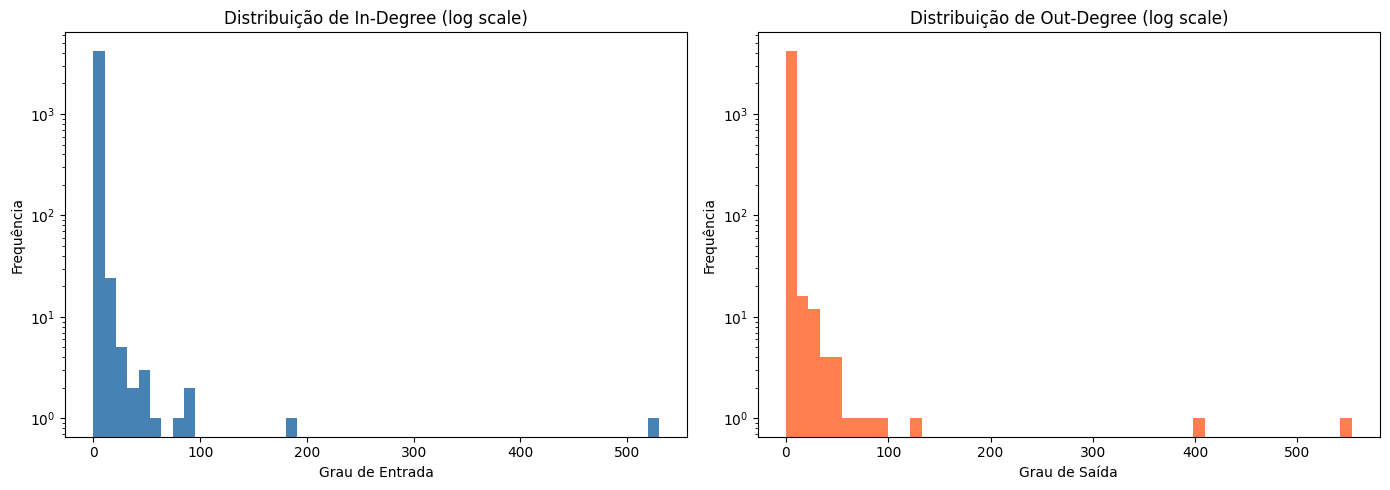

In [11]:
import matplotlib.pyplot as plt

in_degrees  = [d for _, d in G.in_degree()]
out_degrees = [d for _, d in G.out_degree()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(in_degrees,  bins=50, log=True, color='steelblue')
axes[0].set_title('Distribuição de In-Degree (log scale)')
axes[0].set_xlabel('Grau de Entrada')
axes[0].set_ylabel('Frequência')

axes[1].hist(out_degrees, bins=50, log=True, color='coral')
axes[1].set_title('Distribuição de Out-Degree (log scale)')
axes[1].set_xlabel('Grau de Saída')
axes[1].set_ylabel('Frequência')

plt.tight_layout()
plt.savefig('degree_distribution.png', dpi=150)
plt.show()

### 5.2 Strongly Connected Components (SCCs)

Since the graph is directed, we compute **Strongly Connected Components** instead of simple connected components. 
A large dominant SCC (the 'giant component') indicates a core of wallets that are mutually reachable, 
while thousands of isolated nodes (SCCs of size 1) represent wallets that only sent or only received tokens.

In [12]:
sccs = list(nx.strongly_connected_components(G))
scc_sizes = sorted([len(c) for c in sccs], reverse=True)

print(f"Number of SCCs:          {len(sccs):,}")
print(f"Largest SCC size:    {scc_sizes[0]:,}")
print(f"Isolated SCCs (size 1): {scc_sizes.count(1):,}")
print(f"Top 10 sizes: {scc_sizes[:10]}")

Número de CFCs:          3,533
Tamanho da maior CFC:    671
CFCs de tamanho 1 (isolated): 3,500
Top 10 tamanhos: [671, 4, 4, 4, 3, 3, 3, 3, 3, 3]


### 5.3 SCC Size Distribution

The distribution of SCC sizes reveals the fragmentation structure of the network. 
Plotted on a log scale to make the long tail visible.

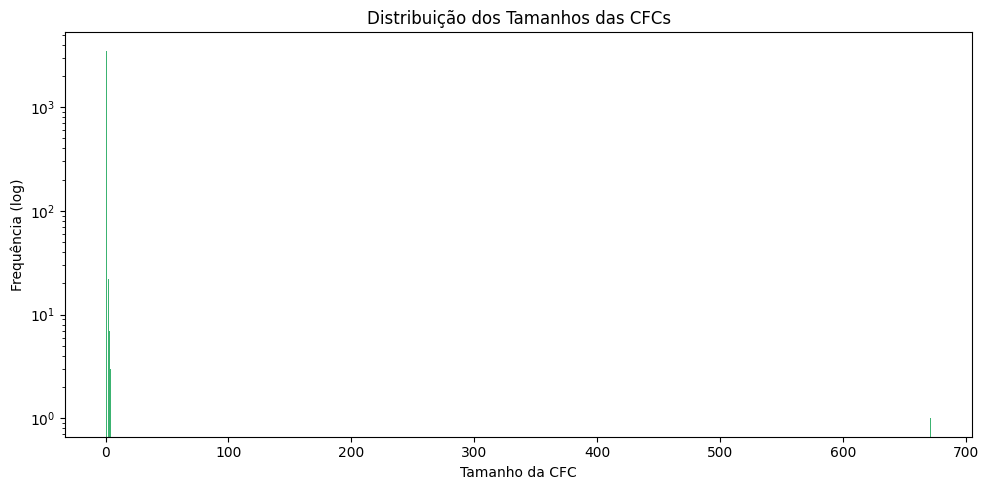

In [13]:
from collections import Counter

size_dist = Counter(scc_sizes)

plt.figure(figsize=(10, 5))
plt.bar(size_dist.keys(), size_dist.values(), log=True, color='mediumseagreen')
plt.xlabel('SCC Size')
plt.ylabel('Frequency (log)')
plt.title('SCC Size Distribution')
plt.tight_layout()
plt.savefig('scc_distribution.png', dpi=150)
plt.show()

## 6. Export

Export the graph in **GraphML** format (for Gephi visualization) and as an **edge list CSV** (for repository submission). 
These files are the graph instances required for the partial delivery.

In [25]:
import os
from google.colab import files

# Export graph files
nx.write_graphml(G, "trump_graph.graphml")
nx.write_edgelist(G, "trump_edgelist.csv", delimiter=",", data=["weight"])

print(f"trump_graph.graphml: {os.path.getsize('trump_graph.graphml')/1024:.1f} KB")
print(f"trump_edgelist.csv:  {os.path.getsize('trump_edgelist.csv')/1024:.1f} KB")

# Option A: download directly to your machine
files.download("trump_graph.graphml")
files.download("trump_edgelist.csv")

# Option B: save to Google Drive (uncomment to use)
# from google.colab import drive
# drive.mount("/content/drive")
# import shutil
# shutil.copy("trump_graph.graphml", "/content/drive/MyDrive/trump_graph.graphml")
# shutil.copy("trump_edgelist.csv",  "/content/drive/MyDrive/trump_edgelist.csv")


trump_graph.graphml: 1137.4 KB
trump_edgelist.csv:  568.9 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>